# Checkpoint 2: Full EDA + Cleaning


## 1. Load and quick overview

In [82]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 70)
sns.set_style("whitegrid")


In [83]:
df = pd.read_csv("house_sale.csv")
df

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,92000.0,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,vipped,featured,NaN,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,NaN,95000.0,AZN,Elçin,mülkiyyətçi,NaN,NaN,Qaraçuxur qəs.,40.393614,49.981553,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,NaN,Obyekt,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,NaN,NaN,Agentlik,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,d71cf9a9-86dd-4162-b540-6252a8659a09,22d840df-9283-4112-bc71-7432511fc776,/items/4638863,2024-10-05 22:14:10.089116+00,Əhmədli qəs. Qaçaq Nəbi küçəsi 3 otaga duzelm...

In [84]:
df.shape

(100775, 51)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100775 entries, 0 to 100774
Data columns (total 51 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_x                 100775 non-null  object 
 1   rel_url              100775 non-null  object 
 2   estate_rel_url_x     100775 non-null  object 
 3   datetime_scrape_x    100775 non-null  object 
 4   price                100775 non-null  float64
 5   currency_x           100775 non-null  object 
 6   location             100775 non-null  object 
 7   attributes           100775 non-null  object 
 8   city_when            100775 non-null  object 
 9   city                 100775 non-null  object 
 10  day_x                100775 non-null  object 
 11  hour_x               100775 non-null  object 
 12  repair               81612 non-null   object 
 13  vip                  8596 non-null    object 
 14  featured             3149 non-null    object 
 15  products_label   

In [86]:
null_counts = df.isnull().sum()
print("Columns with missing values:", (null_counts > 0).sum())


Columns with missing values: 19


In [87]:
null_percent = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({"null_count": null_counts, "null_percent": null_percent}).sort_values("null_percent", ascending = False)
null_summary[null_summary["null_count"] > 0].head(15)

,null_count,null_percent
Binanın növü,100621,99.85
featured,97626,96.88
vip,92179,91.47
Torpaq sahəsi,85204,84.55
hour_y,85144,84.49
İpoteka,67836,67.31
mortgage,67836,67.31
shop_title,28757,28.54
shop_name,28757,28.54
products_label,28145,27.93


100,775 rows, 51 columns. Several columns are almost entirely empty ,these look like boolean-style fields where "missing" actually means "this status doesn't apply," not random missingness.

In [88]:
print("Full-row duplicates:", df.duplicated().sum())

Full-row duplicates: 0


## 2. Cleaning, per-column strategy

Instead of one blanket rule for every missing value, each column gets a decision based on what the missingness actually means.



In [89]:
df_clean = df.copy()
df_clean = df_clean.drop(columns = ["Binanın növü", "hour_y"])

In [90]:
df_clean["featured_flag"] = df_clean["featured"].notnull()
df_clean["vip_flag"] = df_clean["vip"].notnull()
df_clean["mortgage_flag"] = df_clean["mortgage"].notnull()


In [91]:
df_clean["bill_of_sale_flag"] = df_clean["Çıxarış"].str.strip().str.lower().map({"var": 1, "yoxdur": 0})
df_clean = df_clean.drop(columns = ["featured", "vip", "mortgage", "İpoteka", "bill_of_sale", "Çıxarış", "repair"])
df_clean["Təmir"] = df_clean["Təmir"].fillna("Unknown")

In [92]:
def seller_type(row):
    if pd.notnull(row["shop_name"]):
        return "Agency"
    elif pd.notnull(row["owner_name"]):
        return "Individual"
    return "Unknown"

In [93]:
df_clean["seller_type"] = df_clean.apply(seller_type, axis = 1)

In [94]:
for col in ["shop_name", "shop_title", "owner_name", "owner_title"]:
    df_clean[col] = df_clean[col].fillna("N/A")

In [95]:
df_clean["products_label"] = df_clean["products_label"].fillna("Regular listing")
df_clean["description"] = df_clean["description"].fillna("")

In [96]:
def parse_area(val):
    if pd.isnull(val):
        return np.nan
    val = val.strip()
    if "sot" in val:
        return float(val.replace("sot", "").strip().replace(",", ".")) * 100
    return float(val.replace("m²", "").strip().replace(" ", ""))

In [97]:
df_clean["Sahə_numeric"] = df_clean["Sahə"].apply(parse_area)
df_clean["unit_price_calculated"] = (df_clean["price"] / df_clean["Sahə_numeric"]).round(2)
df_clean = df_clean.drop(columns=["unit_price"])

In [98]:
applicable_categories = ["Köhnə tikili", "Yeni tikili", "Ofis", "Həyət evi/Bağ evi"]
mask = df_clean["Kateqoriya"].isin(applicable_categories)
medians = df_clean.loc[mask].groupby("Kateqoriya")["Otaq sayı"].median()

In [99]:
for cat, med in medians.items():
    idx = df_clean[(df_clean["Kateqoriya"] == cat) & (df_clean["Otaq sayı"].isnull())].index
    df_clean.loc[idx, "Otaq sayı"] = med

In [100]:
print("Shape after null handling:", df_clean.shape)
print("Remaining columns with nulls:", (df_clean.isnull().sum() > 0).sum())

Shape after null handling: (100775, 48)
Remaining columns with nulls: 3


## 3. Outlier detection and processing

Price and area are highly skewed, so a single global cutoff would either miss category-specific outliers or wrongly flag normal listings in an expensive category.

First, an obvious sanity-check filter: remove listings priced below 1,000 AZN, these are clearly data-entry errors, not real sale prices.

Then, IQR bounds computed separately per property category (Kateqoriya), since "normal" price/area ranges are very different for a garage vs. an apartment.

Outliers are capped (winsorized) rather than dropped, so real high-end listings aren't lost, just brought back to a reasonable bound. An is_outlier_* flag is kept for each capped column.


In [101]:
before = len(df_clean)
df_clean = df_clean[df_clean["price"] >= 1000].copy()
print(f"Rows removed by sanity check (price < 1000 AZN): {before - len(df_clean)}")

Rows removed by sanity check (price < 1000 AZN): 10


In [102]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


In [103]:
def cap_grouped(df, col, group_col="Kateqoriya", k=1.5):
    capped = df[col].copy()
    flag = pd.Series(False, index=df.index)
    for cat, group in df.groupby(group_col):
        low, high = iqr_bounds(group[col].dropna(), k)
        idx = group.index
        below = df.loc[idx, col] < low
        above = df.loc[idx, col] > high
        flag.loc[idx[below | above]] = True
        capped.loc[idx[below]] = low
        capped.loc[idx[above]] = high
    return capped, flag

In [104]:
df_clean["price_capped"], df_clean["is_outlier_price"] = cap_grouped(df_clean, "price")
df_clean["Sahə_numeric_capped"], df_clean["is_outlier_area"] = cap_grouped(df_clean, "Sahə_numeric")
df_clean["unit_price_capped"], df_clean["is_outlier_unit_price"] = cap_grouped(df_clean, "unit_price_calculated")

In [105]:
low_v, high_v = iqr_bounds(df_clean["views"])
df_clean["views_capped"] = df_clean["views"].clip(low_v, high_v)
df_clean["is_outlier_views"] = (df_clean["views"] < low_v) | (df_clean["views"] > high_v)

In [106]:
print("Outlier percentages (capped, not removed):")
for c in ["is_outlier_price", "is_outlier_area", "is_outlier_unit_price", "is_outlier_views"]:
    print(f"  {c}: {df_clean[c].mean()*100:.2f}%")

Outlier percentages (capped, not removed):
  is_outlier_price: 5.80%
  is_outlier_area: 4.05%
  is_outlier_unit_price: 3.33%
  is_outlier_views: 10.36%


In [107]:
print("Price range before capping: 1000 -", df["price"].max())
print("Price range after capping :", df_clean["price_capped"].min(), "-", df_clean["price_capped"].max())

Price range before capping: 1000 - 600000000.0
Price range after capping : 1000.0 - 3000000.0


## 4. A few extra fields for the EDA

Two lightweight fields help the EDA visuals below make more sense: location_type and floor_ratio.


In [108]:
floor_split = df_clean["Mərtəbə"].str.split("/", expand = True)
df_clean["floor_current"] = pd.to_numeric(floor_split[0].str.strip(), errors = "coerce")
df_clean["floor_total"] = pd.to_numeric(floor_split[1].str.strip(), errors = "coerce")
df_clean["floor_ratio"] = (df_clean["floor_current"] / df_clean["floor_total"]).round(2)

In [109]:
def loc_type(loc):
    if pd.isnull(loc):
        return "Unknown"
    match = re.search(r"\s(r|m|q)\.$", loc.strip())
    mapping = {"r": "District center", "m": "Near metro", "q": "Settlement"}
    return mapping.get(match.group(1), "Other") if match else "Other"

In [110]:
df_clean["location_type"] = df_clean["location"].apply(loc_type)

In [111]:
print("Final cleaned shape:", df_clean.shape)

Final cleaned shape: (100765, 60)


## 5. EDA - distributions

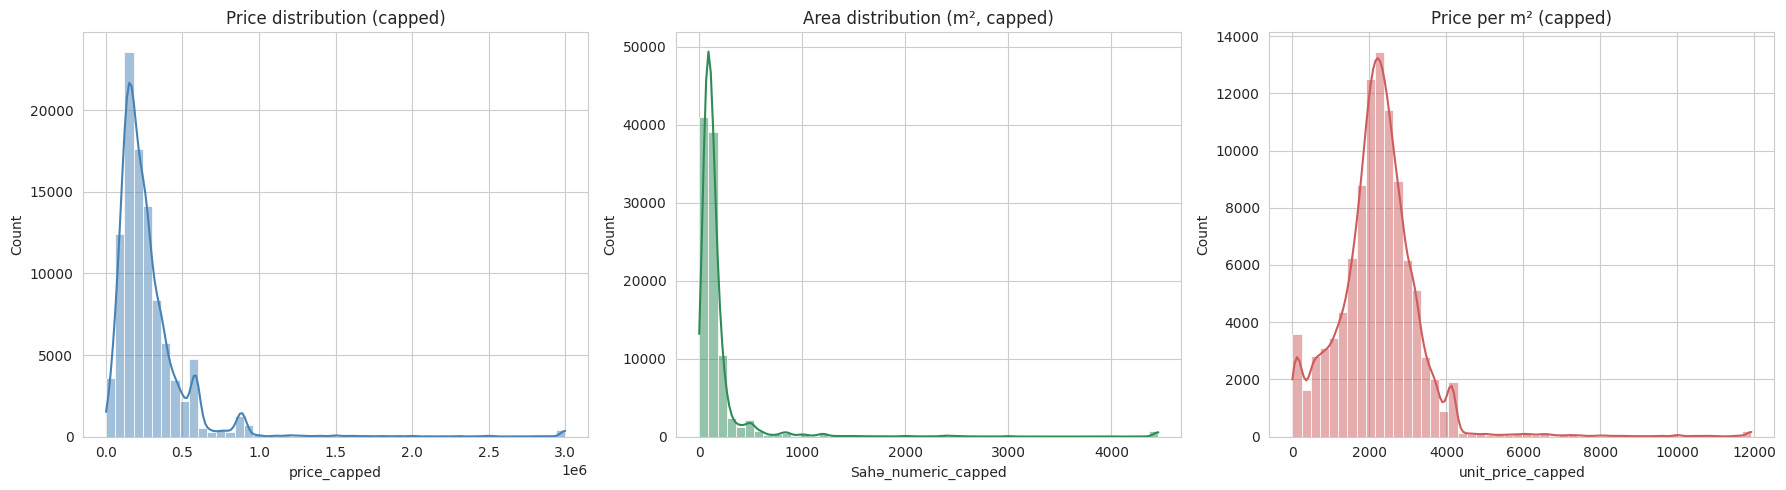

In [112]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
sns.histplot(df_clean["price_capped"], bins = 50, kde = True, ax = axes[0], color = "steelblue")
axes[0].set_title("Price distribution (capped)")
sns.histplot(df_clean["Sahə_numeric_capped"], bins = 50, kde = True, ax = axes[1], color = "seagreen")
axes[1].set_title("Area distribution (m², capped)")
sns.histplot(df_clean["unit_price_capped"], bins = 50, kde = True, ax = axes[2], color = "indianred")
axes[2].set_title("Price per m² (capped)")
plt.tight_layout()
plt.show()


all three distributions are right-skewed even after capping. Most listings cluster at the lower end, with a long tail of pricier properties.

The strong right skew suggests that price may benefit from careful preprocessing and robust regression approaches.

## 6. EDA - correlation heatmap

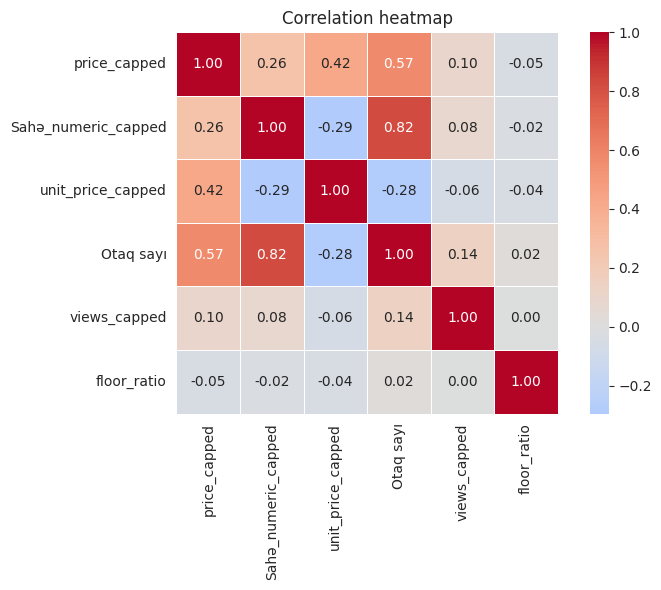

In [113]:
numeric_cols = ["price_capped", "Sahə_numeric_capped", "unit_price_capped", "Otaq sayı",
                 "views_capped", "floor_ratio"]
corr = df_clean[numeric_cols].corr()
plt.figure(figsize = (8, 6))
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0, square = True, linewidths = 0.5)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()


Sahə_numeric_capped (area) has the strongest correlation with price, which makes intuitive sense, bigger properties cost more. Otaq sayı (room count) is also positively correlated, but more weakly, since room count is a coarser signal than exact area. floor_ratio and views_capped barely correlate with price on their own.

## 7. EDA - categorical breakdown

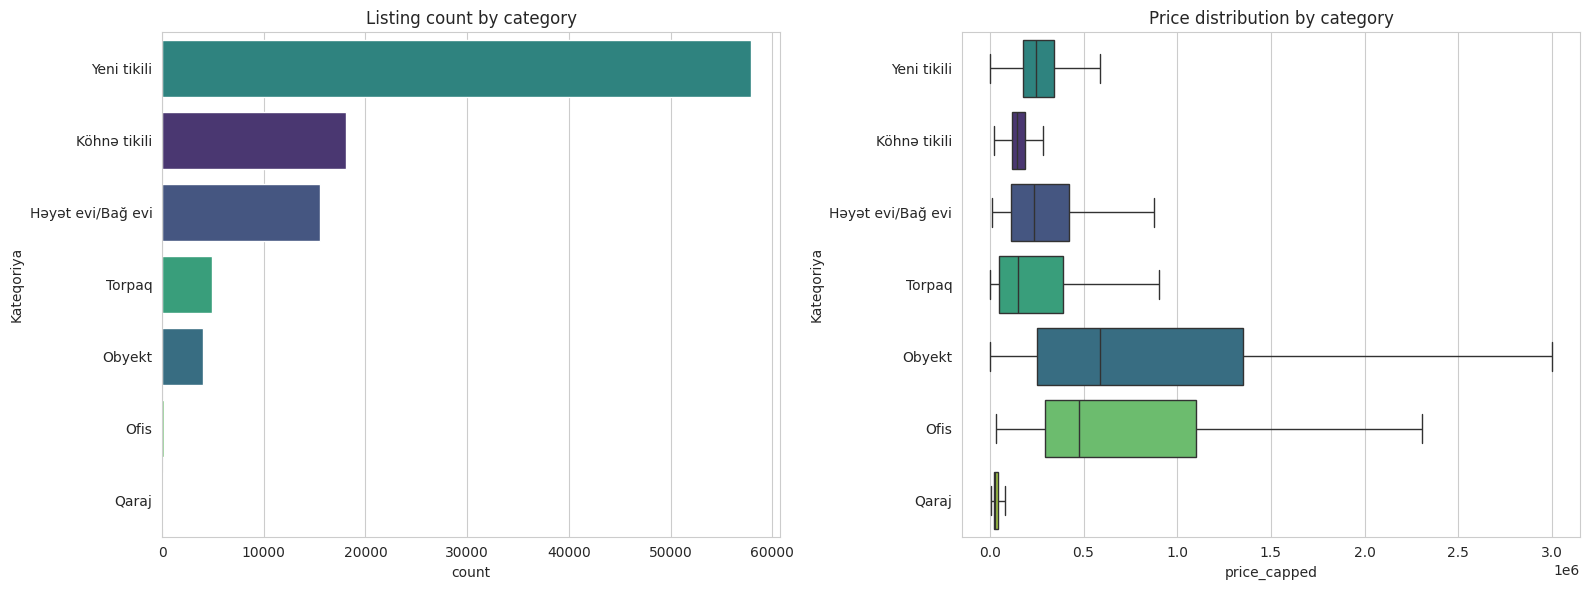

In [114]:
order = df_clean["Kateqoriya"].value_counts().index
fig, axes = plt.subplots(1, 2, figsize = (16, 6))
sns.countplot(data = df_clean, y = "Kateqoriya", order = order, ax = axes[0], hue = "Kateqoriya", legend = False, palette = "viridis")
axes[0].set_title("Listing count by category")
sns.boxplot(data = df_clean, x = "price_capped", y = "Kateqoriya", order = order, ax = axes[1], hue = "Kateqoriya", legend = False, palette="viridis")
axes[1].set_title("Price distribution by category")
plt.tight_layout()
plt.show()


In [115]:
category_share = (df_clean["Kateqoriya"].value_counts(normalize = True) * 100).round(1)
category_median_price = df_clean.groupby("Kateqoriya")["price_capped"].median().sort_values(ascending = False)
location_median_price = df_clean.groupby("location_type")["price_capped"].median().sort_values(ascending = False)

In [116]:
print("Apartment segment share (Yeni tikili + Köhnə tikili):",
      round(category_share[["Yeni tikili", "Köhnə tikili"]].sum(), 1), "%")

Apartment segment share (Yeni tikili + Köhnə tikili): 75.5 %


In [117]:
print("Most vs least expensive category ratio:",
      round(category_median_price.max() / category_median_price.min(), 1), "x")

Most vs least expensive category ratio: 19.7 x


In [118]:
print("Median price by location type:")
print(location_median_price)

Median price by location type:
location_type
District center    250000.0
Near metro         230000.0
Settlement         173000.0
Other               87000.0
Name: price_capped, dtype: float64


the apartment segment ("Yeni tikili" + "Köhnə tikili") makes up the large majority of listings, and property category alone spreads the median price by a wide margin, a strong signal that "Kateqoriya" will matter a lot for the model. "location_type" also clearly separates price levels, with district-center listings priced highest.

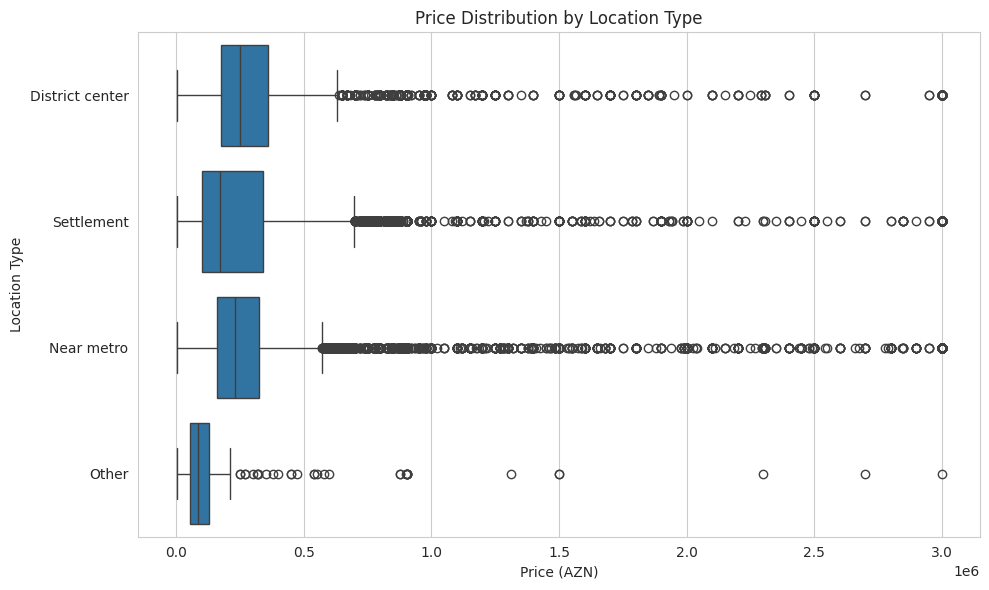

In [120]:
plt.figure(figsize = (10, 6))

sns.boxplot(
    data = df_clean,
    x = "price_capped",
    y = "location_type"
)

plt.title("Price Distribution by Location Type")
plt.xlabel("Price (AZN)")
plt.ylabel("Location Type")
plt.tight_layout()
plt.show()